# Моделирование

In [1]:
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier, Pool

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

df = pd.read_excel("FINAL_delivery.xlsx")

TARGET = "delivery"
DROP_TARGETS = ["pregnancy", "delivery"]

SPARSE_DROP = [
    "oocytes_retrieved",
    "bleeding_volume",
    "painful_periods",
    "menstruation_established",
    "cycle_regular",
]

X = df.drop(columns=DROP_TARGETS + SPARSE_DROP, errors="ignore")
y = df[TARGET].astype(int)

print("Rows:", len(df))
print("Target balance:\n", y.value_counts().to_dict())
print("Features:", X.shape[1])


Rows: 195
Target balance:
 {0: 108, 1: 87}
Features: 30


In [2]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_freq: int = 5):
        self.min_freq = min_freq

    def fit(self, X, y=None):
        X = X.copy()
        self.object_cols_ = [c for c in X.columns if X[c].dtype == "object"]
        self.keep_values_ = {}

        for col in self.object_cols_:
            vc = X[col].fillna("Missing").astype(str).value_counts()
            self.keep_values_[col] = set(vc[vc >= self.min_freq].index.tolist())

        return self

    def transform(self, X):
        X = X.copy()
        for col in self.object_cols_:
            vals = X[col].fillna("Missing").astype(str)
            X[col] = vals.where(vals.isin(self.keep_values_[col]), "Other")
        return X


In [3]:
def pick_best_threshold(y_true, probs, metric="f1"):
    best_thr = 0.5
    best_score = -1.0

    for thr in np.arange(0.05, 0.96, 0.01):
        pred = (probs >= thr).astype(int)

        if metric == "f1":
            score = f1_score(y_true, pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("metric must be 'f1' or 'recall'")

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr, float(best_score)

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

In [5]:
print("=== РАЗМЕРЫ ВЫБОРОК ===")
print(f"Train       : {X_train.shape[0]}")
print(f"Validation  : {X_val.shape[0]}")
print(f"Test        : {X_test.shape[0]}")
print(f"Всего       : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

=== РАЗМЕРЫ ВЫБОРОК ===
Train       : 117
Validation  : 39
Test        : 39
Всего       : 195


In [6]:
rare_grouper = RareCategoryGrouper(min_freq=5).fit(X_train)

X_train_rg = rare_grouper.transform(X_train)
X_val_rg   = rare_grouper.transform(X_val)
X_test_rg  = rare_grouper.transform(X_test)

numeric_features = X_train_rg.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_rg.select_dtypes(include=["object"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ]
)

### Logistic Regression

In [7]:
def run_lr_cv(X, y, preprocessor, rare_grouper, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    thr_list = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()
        
        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        
        X_tr_p = preprocessor.fit_transform(X_tr)
        X_val_p = preprocessor.transform(X_val)
        
        model = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED,
        )
        model.fit(X_tr_p, y_tr)
        
        val_prob = model.predict_proba(X_val_p)[:, 1]
        
        best_thr, _ = pick_best_threshold(y_val.values, val_prob, metric="f1")
        val_pred = (val_prob >= best_thr).astype(int)
        thr_list.append(best_thr)
        
        f1 = f1_score(y_val, val_pred)
        auc = roc_auc_score(y_val, val_prob)
        acc = accuracy_score(y_val, val_pred)
        prec = precision_score(y_val, val_pred, zero_division=0)
        rec = recall_score(y_val, val_pred, zero_division=0)
        
        f1_list.append(f1)
        auc_list.append(auc)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        
        print(f"Fold {fold+1}: F1={f1:.4f} | AUC={auc:.4f} | Acc={acc:.4f} | Thr={best_thr:.2f}")
    
    print("\n" + "="*55)
    print("Logistic Regression 5-Fold CV Results")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    
    return {
        'f1_mean': np.mean(f1_list), 'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list), 'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'cv_threshold': float(np.median(thr_list))
    }

print("\n=== 5-FOLD STRATIFIED CV (Logistic Regression) ===")
lr_cv = run_lr_cv(X_train_full, y_train_full, preprocessor, rare_grouper, n_splits=5)


=== 5-FOLD STRATIFIED CV (Logistic Regression) ===

=== Fold 1/5 ===
Fold 1: F1=0.6286 | AUC=0.5794 | Acc=0.5938 | Thr=0.22

=== Fold 2/5 ===
Fold 2: F1=0.8750 | AUC=0.8739 | Acc=0.8710 | Thr=0.35

=== Fold 3/5 ===
Fold 3: F1=0.7500 | AUC=0.7857 | Acc=0.7419 | Thr=0.43

=== Fold 4/5 ===
Fold 4: F1=0.6190 | AUC=0.5756 | Acc=0.4839 | Thr=0.08

=== Fold 5/5 ===
Fold 5: F1=0.6829 | AUC=0.6765 | Acc=0.5806 | Thr=0.12

Logistic Regression 5-Fold CV Results
F1-score:  0.7111 ± 0.0943
AUC-ROC:   0.6982 ± 0.1168
Accuracy:  0.6542 ± 0.1362
Precision: 0.5902 ± 0.1153
Recall:    0.9143 ± 0.0833


### Random Forest

In [8]:
def run_rf_cv(X, y, preprocessor, rare_grouper, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    thr_list = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()
        
        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        
        X_tr_p = preprocessor.fit_transform(X_tr)
        X_val_p = preprocessor.transform(X_val)
        
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_split=5,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
        model.fit(X_tr_p, y_tr)
        
        val_prob = model.predict_proba(X_val_p)[:, 1]
        
        best_thr, _ = pick_best_threshold(y_val.values, val_prob, metric="f1")
        val_pred = (val_prob >= best_thr).astype(int)
        thr_list.append(best_thr)
        
        f1 = f1_score(y_val, val_pred)
        auc = roc_auc_score(y_val, val_prob)
        acc = accuracy_score(y_val, val_pred)
        prec = precision_score(y_val, val_pred, zero_division=0)
        rec = recall_score(y_val, val_pred, zero_division=0)
        
        f1_list.append(f1)
        auc_list.append(auc)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        
        print(f"Fold {fold+1}: F1={f1:.4f} | AUC={auc:.4f} | Acc={acc:.4f} | Thr={best_thr:.2f}")
    
    print("\n" + "="*55)
    print("Random Forest 5-Fold CV Results")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    
    return {
        'f1_mean': np.mean(f1_list), 'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list), 'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'cv_threshold': float(np.median(thr_list))
    }


# ==================== ЗАПУСК ====================
print("\n=== 5-FOLD STRATIFIED CV (Random Forest) ===")
rf_cv = run_rf_cv(X_train_full, y_train_full, preprocessor, rare_grouper, n_splits=5)


=== 5-FOLD STRATIFIED CV (Random Forest) ===

=== Fold 1/5 ===
Fold 1: F1=0.6667 | AUC=0.6270 | Acc=0.6250 | Thr=0.37

=== Fold 2/5 ===
Fold 2: F1=0.7027 | AUC=0.7185 | Acc=0.6452 | Thr=0.31

=== Fold 3/5 ===
Fold 3: F1=0.7429 | AUC=0.7605 | Acc=0.7097 | Thr=0.37

=== Fold 4/5 ===
Fold 4: F1=0.6829 | AUC=0.6891 | Acc=0.5806 | Thr=0.20

=== Fold 5/5 ===
Fold 5: F1=0.7000 | AUC=0.7017 | Acc=0.6129 | Thr=0.30

Random Forest 5-Fold CV Results
F1-score:  0.6990 ± 0.0255
AUC-ROC:   0.6993 ± 0.0435
Accuracy:  0.6347 ± 0.0429
Precision: 0.5573 ± 0.0343
Recall:    0.9429 ± 0.0535


### CatBoost

In [9]:
cat_cols = categorical_features

def run_cb_cv(X, y, rare_grouper, cat_cols, n_splits=5):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    thr_list = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")

        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()

        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        for col in cat_cols:
            X_tr[col]  = X_tr[col].fillna("Missing").astype(str)
            X_val[col] = X_val[col].fillna("Missing").astype(str)

        tr_pool  = Pool(X_tr,  y_tr,  cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)

        fold_model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=5.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=SEED,
            verbose=False,
            auto_class_weights="Balanced",
            od_type="Iter",
            od_wait=150,
        )

        fold_model.fit(tr_pool, eval_set=val_pool, use_best_model=True)

        val_prob = fold_model.predict_proba(val_pool)[:, 1]

        best_thr, _ = pick_best_threshold(y_val.values, val_prob, metric="f1")
        val_pred = (val_prob >= best_thr).astype(int)
        thr_list.append(best_thr)

        f1_list.append(f1_score(y_val, val_pred))
        auc_list.append(roc_auc_score(y_val, val_prob))
        acc_list.append(accuracy_score(y_val, val_pred))
        prec_list.append(precision_score(y_val, val_pred, zero_division=0))
        rec_list.append(recall_score(y_val, val_pred, zero_division=0))

        print(f"Fold {fold+1}: F1={f1_list[-1]:.4f} | AUC={auc_list[-1]:.4f} | Thr={best_thr:.2f}")

    cv_threshold = float(np.median(thr_list))
    print(f"CV threshold (median): {cv_threshold:.4f}  | folds: {[round(t,2) for t in thr_list]}")


    print("\n" + "="*55)
    print("CatBoost 5-Fold CV Results (mean ± std)")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")

    return {
        'f1_mean': np.mean(f1_list),   'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list),'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'cv_threshold': cv_threshold,
    }

cb_cv = run_cb_cv(X_train_full, y_train_full, rare_grouper, cat_cols)


=== Fold 1/5 ===
Fold 1: F1=0.6512 | AUC=0.6071 | Thr=0.30

=== Fold 2/5 ===
Fold 2: F1=0.7027 | AUC=0.7059 | Thr=0.21

=== Fold 3/5 ===
Fold 3: F1=0.8333 | AUC=0.8046 | Thr=0.50

=== Fold 4/5 ===
Fold 4: F1=0.6897 | AUC=0.6975 | Thr=0.49

=== Fold 5/5 ===
Fold 5: F1=0.7273 | AUC=0.8277 | Thr=0.50
CV threshold (median): 0.4900  | folds: [0.3, 0.21, 0.5, 0.49, 0.5]

CatBoost 5-Fold CV Results (mean ± std)
F1-score:  0.7208 ± 0.0614
AUC-ROC:   0.7286 ± 0.0798
Accuracy:  0.6933 ± 0.1102
Precision: 0.6692 ± 0.1769
Recall:    0.8429 ± 0.1143


### MLP

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(X_train, y_train, X_val, y_val):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
    y_val_np  = y_val.values

    model = MLP(input_dim=X_train_t.shape[1])

    pos_count = y_train_t.sum().item()
    neg_count = len(y_train_t) - pos_count
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=10
    )

    val_f1_history = []
    val_auc_history = []
    best_val_f1 = -1.0
    best_state = None
    best_epoch = 0
    patience = 40
    counter = 0

    for epoch in range(400):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy().ravel()

        _, val_f1 = pick_best_threshold(y_val_np, val_prob, metric="f1")
        val_auc = roc_auc_score(y_val_np, val_prob)

        val_f1_history.append(val_f1)
        val_auc_history.append(val_auc)

        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy().ravel()

    best_thr, _ = pick_best_threshold(y_val_np, val_prob, metric="f1")

    return model, best_thr, best_epoch, val_f1_history, val_auc_history

In [11]:
def run_mlp_cv(X, y, preprocessor, rare_grouper, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    all_histories = []

    thr_list = []
    epoch_list = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()
        
        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        
        X_tr_proc = preprocessor.fit_transform(X_tr)   
        X_val_proc = preprocessor.transform(X_val)     
        
        model, best_thr, best_epoch, val_f1_hist, val_auc_hist = train_mlp(
            X_tr_proc, y_tr, X_val_proc, y_val
        )
        thr_list.append(best_thr)
        epoch_list.append(best_epoch)
        
        all_histories.append({
            'fold': fold+1,
            'f1_hist': val_f1_hist,
            'auc_hist': val_auc_hist,
            'best_epoch': best_epoch,
            'best_thr': best_thr
        })
        
        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val_proc, dtype=torch.float32))
            val_probs = torch.sigmoid(val_logits).numpy().flatten()
        
        val_pred = (val_probs >= best_thr).astype(int)
        
        f1 = f1_score(y_val, val_pred)
        auc = roc_auc_score(y_val, val_probs)
        acc = accuracy_score(y_val, val_pred)
        prec = precision_score(y_val, val_pred, zero_division=0)
        rec = recall_score(y_val, val_pred, zero_division=0)
        
        f1_list.append(f1)
        auc_list.append(auc)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        
        print(f"Fold {fold+1}: F1={f1:.4f} | AUC={auc:.4f} | Acc={acc:.4f} | Thr={best_thr:.2f}")
    
    print("\n" + "="*55)
    print("MLP 5-Fold CV Results (mean ± std)")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    
    return {
        'f1_mean': np.mean(f1_list), 'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list), 'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'histories': all_histories,
        'cv_threshold': float(np.median(thr_list)),
        'cv_best_epoch': int(np.median(epoch_list)),
    }

mlp_cv  = run_mlp_cv(
    X_train_full, y_train_full,
    preprocessor, rare_grouper,
    n_splits=5
)


=== Fold 1/5 ===
Fold 1: F1=0.7333 | AUC=0.6825 | Acc=0.7500 | Thr=0.50

=== Fold 2/5 ===
Fold 2: F1=0.7222 | AUC=0.7101 | Acc=0.6774 | Thr=0.42

=== Fold 3/5 ===
Fold 3: F1=0.6875 | AUC=0.6933 | Acc=0.6774 | Thr=0.44

=== Fold 4/5 ===
Fold 4: F1=0.6512 | AUC=0.6597 | Acc=0.5161 | Thr=0.51

=== Fold 5/5 ===
Fold 5: F1=0.7333 | AUC=0.7563 | Acc=0.7419 | Thr=0.48

MLP 5-Fold CV Results (mean ± std)
F1-score:  0.7055 ± 0.0320
AUC-ROC:   0.7004 ± 0.0324
Accuracy:  0.6726 ± 0.0841
Precision: 0.6120 ± 0.0756
Recall:    0.8571 ± 0.0904


In [12]:
comparison_data = [
    {
        "Model": "Logistic Regression",
        "F1-score": f"{lr_cv['f1_mean']:.4f} ± {lr_cv['f1_std']:.4f}",
        "AUC-ROC": f"{lr_cv['auc_mean']:.4f} ± {lr_cv['auc_std']:.4f}",
        "Accuracy": f"{lr_cv['acc_mean']:.4f} ± {lr_cv['acc_std']:.4f}",
        "Precision": f"{lr_cv['prec_mean']:.4f} ± {lr_cv['prec_std']:.4f}",
        "Sensitivity ": f"{lr_cv['rec_mean']:.4f} ± {lr_cv['rec_std']:.4f}",
    },
    {
        "Model": "Random Forest",
        "F1-score": f"{rf_cv['f1_mean']:.4f} ± {rf_cv['f1_std']:.4f}",
        "AUC-ROC": f"{rf_cv['auc_mean']:.4f} ± {rf_cv['auc_std']:.4f}",
        "Accuracy": f"{rf_cv['acc_mean']:.4f} ± {rf_cv['acc_std']:.4f}",
        "Precision": f"{rf_cv['prec_mean']:.4f} ± {rf_cv['prec_std']:.4f}",
        "Sensitivity ": f"{rf_cv['rec_mean']:.4f} ± {rf_cv['rec_std']:.4f}",
    },
    {
        "Model": "CatBoost",
        "F1-score": f"{cb_cv['f1_mean']:.4f} ± {cb_cv['f1_std']:.4f}",
        "AUC-ROC": f"{cb_cv['auc_mean']:.4f} ± {cb_cv['auc_std']:.4f}",
        "Accuracy": f"{cb_cv['acc_mean']:.4f} ± {cb_cv['acc_std']:.4f}",
        "Precision": f"{cb_cv['prec_mean']:.4f} ± {cb_cv['prec_std']:.4f}",
        "Sensitivity ": f"{cb_cv['rec_mean']:.4f} ± {cb_cv['rec_std']:.4f}",
    },
    {
        "Model": "MLP (PyTorch)",
        "F1-score": f"{mlp_cv ['f1_mean']:.4f} ± {mlp_cv ['f1_std']:.4f}",
        "AUC-ROC": f"{mlp_cv ['auc_mean']:.4f} ± {mlp_cv ['auc_std']:.4f}",
        "Accuracy": f"{mlp_cv ['acc_mean']:.4f} ± {mlp_cv ['acc_std']:.4f}",
        "Precision": f"{mlp_cv ['prec_mean']:.4f} ± {mlp_cv ['prec_std']:.4f}",
        "Sensitivity ": f"{mlp_cv ['rec_mean']:.4f} ± {mlp_cv ['rec_std']:.4f}",
    },
]

results_cv = pd.DataFrame(comparison_data).sort_values(
    by="F1-score", ascending=False
).reset_index(drop=True)

print("\n" + "="*90)
print("СРАВНЕНИЕ МОДЕЛЕЙ (5-Fold Stratified Cross-Validation)")
print("="*90)
print(results_cv.to_string(index=False))
print("="*90)

best_model = results_cv.loc[0, "Model"]
print(f"\nЛучшая модель по F1-score: {best_model}")


СРАВНЕНИЕ МОДЕЛЕЙ (5-Fold Stratified Cross-Validation)
              Model        F1-score         AUC-ROC        Accuracy       Precision    Sensitivity 
           CatBoost 0.7208 ± 0.0614 0.7286 ± 0.0798 0.6933 ± 0.1102 0.6692 ± 0.1769 0.8429 ± 0.1143
Logistic Regression 0.7111 ± 0.0943 0.6982 ± 0.1168 0.6542 ± 0.1362 0.5902 ± 0.1153 0.9143 ± 0.0833
      MLP (PyTorch) 0.7055 ± 0.0320 0.7004 ± 0.0324 0.6726 ± 0.0841 0.6120 ± 0.0756 0.8571 ± 0.0904
      Random Forest 0.6990 ± 0.0255 0.6993 ± 0.0435 0.6347 ± 0.0429 0.5573 ± 0.0343 0.9429 ± 0.0535

Лучшая модель по F1-score: CatBoost


# Финальное обучение MLP

In [13]:
def calculate_clinical_metrics(y_true, y_pred, y_prob=None):
   
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Метрики
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0      # Recall / Чувствительность
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0      # Специфичность
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0        # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0              # NPV
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    metrics = {
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Accuracy': round(accuracy, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'Precision ': round(precision, 4),
        'NPV': round(npv, 4),
        'F1-score': round(f1, 4)
    }
    
    if y_prob is not None:
        metrics['AUC-ROC'] = round(roc_auc_score(y_true, y_prob), 4)
    
    return cm, metrics

In [14]:
seeds = [42, 123, 456, 789, 1011, 2023, 777]   # 7 запусков
results = []

print("=== Запуск финальной MLP с разными seeds ===\n")

def train_mlp_final(X_train, y_train, n_epochs):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

    model = MLP(input_dim=X_train_t.shape[1])
    pos_weight = torch.tensor(
        [(len(y_train_t) - y_train_t.sum()) / y_train_t.sum()], dtype=torch.float32
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    return model

X_train_val_rg = rare_grouper.transform(pd.concat([X_train, X_val]))
X_test_rg      = rare_grouper.transform(X_test)

X_train_val_p  = preprocessor.fit_transform(X_train_val_rg)
X_test_p       = preprocessor.transform(X_test_rg)

best_thr = mlp_cv['cv_threshold'] #средний оптимальный порог по train-валидации (не подобран на test!)

# Запуск
for seed in seeds:
    set_seed(seed)

    final_mlp = train_mlp_final(
        X_train_val_p,
        pd.concat([y_train, y_val]),
        n_epochs=mlp_cv['cv_best_epoch']
    )

    best_thr = mlp_cv['cv_threshold']

    final_mlp.eval()
    with torch.no_grad():
        y_prob = torch.sigmoid(
            final_mlp(torch.tensor(X_test_p, dtype=torch.float32))
        ).numpy().flatten()

    y_pred = (y_prob >= best_thr).astype(int)
    
    cm, metrics = calculate_clinical_metrics(y_test, y_pred, y_prob)
    
    # Добавляем AUC отдельно (на всякий случай)
    metrics['AUC-ROC'] = round(roc_auc_score(y_test, y_prob), 4)
    metrics['Threshold'] = round(best_thr, 4)
    metrics['Seed'] = seed
    
    results.append(metrics)
    
    print(f"Seed {seed}: F1={metrics['F1-score']:.4f} | AUC={metrics['AUC-ROC']:.4f} | Thr={best_thr:.2f}")

df_mlp = pd.DataFrame(results)
df_mlp.to_excel('MLP_results_seeds.xlsx', index=False)

print("\n" + "="*70)
print("MLP — Финальная оценка на Test (mean ± std)")
print("="*70)

summary = {
    'Accuracy':    f"{df_mlp['Accuracy'].mean():.4f} ± {df_mlp['Accuracy'].std():.4f}",
    'Sensitivity': f"{df_mlp['Sensitivity'].mean():.4f} ± {df_mlp['Sensitivity'].std():.4f}",
    'Specificity': f"{df_mlp['Specificity'].mean():.4f} ± {df_mlp['Specificity'].std():.4f}",
    'Precision': f"{df_mlp['Precision '].mean():.4f} ± {df_mlp['Precision '].std():.4f}",
    'NPV': f"{df_mlp['NPV'].mean():.4f} ± {df_mlp['NPV'].std():.4f}",
    'F1-score':    f"{df_mlp['F1-score'].mean():.4f} ± {df_mlp['F1-score'].std():.4f}",
    'AUC-ROC':     f"{df_mlp['AUC-ROC'].mean():.4f} ± {df_mlp['AUC-ROC'].std():.4f}",
}

for metric, value in summary.items():
    print(f"{metric:15}: {value}")

print("\nСредний выбранный порог:", round(df_mlp['Threshold'].mean(), 4))

=== Запуск финальной MLP с разными seeds ===

Seed 42: F1=0.6047 | AUC=0.6070 | Thr=0.48
Seed 123: F1=0.5882 | AUC=0.6176 | Thr=0.48
Seed 456: F1=0.5333 | AUC=0.5535 | Thr=0.48
Seed 789: F1=0.6222 | AUC=0.7112 | Thr=0.48
Seed 1011: F1=0.5128 | AUC=0.5722 | Thr=0.48
Seed 2023: F1=0.6047 | AUC=0.5936 | Thr=0.48
Seed 777: F1=0.5333 | AUC=0.6283 | Thr=0.48

MLP — Финальная оценка на Test (mean ± std)
Accuracy       : 0.5641 ± 0.0645
Sensitivity    : 0.6807 ± 0.1693
Specificity    : 0.4740 ± 0.2285
Precision      : 0.5181 ± 0.0706
NPV            : 0.6582 ± 0.0507
F1-score       : 0.5713 ± 0.0436
AUC-ROC        : 0.6119 ± 0.0508

Средний выбранный порог: 0.48


### ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛЕЙ (на Train + Val → Test)

In [15]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

X_train_val_rg = rare_grouper.transform(X_train_val)
X_test_rg      = rare_grouper.transform(X_test)
X_train_val_p  = preprocessor.fit_transform(X_train_val_rg)
X_test_p       = preprocessor.transform(X_test_rg)

X_train_val_cat = rare_grouper.transform(X_train_val)
X_val_cat       = rare_grouper.transform(X_val)
X_test_cat      = rare_grouper.transform(X_test)

# Убедиться, что категории — строки (CatBoost требует str, не float)
for col in cat_cols:
    X_train_val_cat[col] = X_train_val_cat[col].astype(str)
    X_val_cat[col]       = X_val_cat[col].astype(str)
    X_test_cat[col]      = X_test_cat[col].astype(str)

print("=" * 70)
print("ФИНАЛЬНАЯ ОЦЕНКА BASELINE-МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 70)

final_results = []

# 1. Logistic Regression

logreg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=SEED
)
logreg.fit(X_train_val_p, y_train_val)
best_thr_lr  = lr_cv['cv_threshold']

test_prob_lr = logreg.predict_proba(X_test_p)[:, 1]
test_pred_lr = (test_prob_lr >= best_thr_lr).astype(int)

_, metrics_lr = calculate_clinical_metrics(y_test, test_pred_lr, test_prob_lr)
metrics_lr['Model'] = 'Logistic Regression'
metrics_lr['Threshold'] = round(best_thr_lr, 4)
final_results.append(metrics_lr)

print(f"\nLogistic Regression | Threshold = {best_thr_lr:.4f}")
print(f"F1 = {metrics_lr['F1-score']:.4f} | AUC = {metrics_lr.get('AUC-ROC', 'N/A')}")

# 2. Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_val_p, y_train_val)
best_thr_rf  = rf_cv['cv_threshold']

test_prob_rf = rf.predict_proba(X_test_p)[:, 1]
test_pred_rf = (test_prob_rf >= best_thr_rf).astype(int)

_, metrics_rf = calculate_clinical_metrics(y_test, test_pred_rf, test_prob_rf)
metrics_rf['Model'] = 'Random Forest'
metrics_rf['Threshold'] = round(best_thr_rf, 4)
final_results.append(metrics_rf)

print(f"\nRandom Forest       | Threshold = {best_thr_rf:.4f}")
print(f"F1 = {metrics_rf['F1-score']:.4f} | AUC = {metrics_rf.get('AUC-ROC', 'N/A')}")

# 3. CatBoost

train_val_pool = Pool(X_train_val_cat, y_train_val, cat_features=cat_cols)
val_pool_final = Pool(X_val_cat,       y_val,       cat_features=cat_cols)
test_pool_final= Pool(X_test_cat,      y_test,      cat_features=cat_cols)

cat_model_final = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=5.0,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=SEED,
    verbose=False,
    auto_class_weights="Balanced",
    od_type="Iter",
    od_wait=150,
)
cat_model_final.fit(train_val_pool, use_best_model=False)
best_thr_cat = cb_cv['cv_threshold']

# Финальная оценка на test
test_prob_cat = cat_model_final.predict_proba(test_pool_final)[:, 1]
test_pred_cat = (test_prob_cat >= best_thr_cat).astype(int)

_, metrics_cat = calculate_clinical_metrics(y_test, test_pred_cat, test_prob_cat)
metrics_cat['Model'] = 'CatBoost'
metrics_cat['Threshold'] = round(best_thr_cat, 4)
final_results.append(metrics_cat)

print(f"\nCatBoost            | Threshold = {best_thr_cat:.4f}")
print(f"F1 = {metrics_cat['F1-score']:.4f} | AUC = {metrics_cat.get('AUC-ROC', 'N/A')}")

# Итоговая таблица

df_final = pd.DataFrame(final_results)
df_final = df_final[['Model', 'Threshold', 'Accuracy', 'Sensitivity', 
                     'Specificity', 'Precision ', 'NPV', 'F1-score', 'AUC-ROC']]

print("\n" + "=" * 90)
print("ИТОГОВАЯ ТАБЛИЦА ФИНАЛЬНЫХ BASELINE-МОДЕЛЕЙ (на тестовой выборке)")
print("=" * 90)
print(df_final.to_string(index=False))

ФИНАЛЬНАЯ ОЦЕНКА BASELINE-МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ

Logistic Regression | Threshold = 0.2200
F1 = 0.5417 | AUC = 0.5668

Random Forest       | Threshold = 0.3100
F1 = 0.6154 | AUC = 0.6551

CatBoost            | Threshold = 0.4900
F1 = 0.6061 | AUC = 0.7059

ИТОГОВАЯ ТАБЛИЦА ФИНАЛЬНЫХ BASELINE-МОДЕЛЕЙ (на тестовой выборке)
              Model  Threshold  Accuracy  Sensitivity  Specificity  Precision     NPV  F1-score  AUC-ROC
Logistic Regression       0.22    0.4359       0.7647       0.1818      0.4194 0.5000    0.5417   0.5668
      Random Forest       0.31    0.4872       0.9412       0.1364      0.4571 0.7500    0.6154   0.6551
           CatBoost       0.49    0.6667       0.5882       0.7273      0.6250 0.6957    0.6061   0.7059


In [16]:
results = [
    {
        'Model': 'Logistic Regression',
        'Threshold': metrics_lr['Threshold'],
        'Accuracy': metrics_lr['Accuracy'],
        'Sensitivity': metrics_lr['Sensitivity'],
        'Specificity': metrics_lr['Specificity'],
        'Precision': metrics_lr['Precision '],
        'NPV': metrics_lr['NPV'],
        'F1-score': metrics_lr['F1-score'],
        'AUC-ROC': metrics_lr['AUC-ROC']
    },

    {
        'Model': 'Random Forest',
        'Threshold': metrics_rf['Threshold'],
        'Accuracy': metrics_rf['Accuracy'],
        'Sensitivity': metrics_rf['Sensitivity'],
        'Specificity': metrics_rf['Specificity'],
        'Precision': metrics_rf['Precision '],
        'NPV': metrics_rf['NPV'],
        'F1-score': metrics_rf['F1-score'],
        'AUC-ROC': metrics_rf['AUC-ROC']
    },

    {
        'Model': 'CatBoost',
        'Threshold': metrics_cat['Threshold'],
        'Accuracy': metrics_cat['Accuracy'],
        'Sensitivity': metrics_cat['Sensitivity'],
        'Specificity': metrics_cat['Specificity'],
        'Precision': metrics_cat['Precision '],
        'NPV': metrics_cat['NPV'],
        'F1-score': metrics_cat['F1-score'],
        'AUC-ROC': metrics_cat['AUC-ROC']
    }
]

df_final = pd.DataFrame(results)

mlp_row = {
    'Model': 'MLP (PyTorch)',
    'Threshold': round(df_mlp['Threshold'].mean(), 4),
    'Accuracy':    f"{df_mlp['Accuracy'].mean():.4f} ± {df_mlp['Accuracy'].std():.4f}",
    'Sensitivity': f"{df_mlp['Sensitivity'].mean():.4f} ± {df_mlp['Sensitivity'].std():.4f}",
    'Specificity': f"{df_mlp['Specificity'].mean():.4f} ± {df_mlp['Specificity'].std():.4f}",
    'Precision': f"{df_mlp['Precision '].mean():.4f} ± {df_mlp['Precision '].std():.4f}",
    'NPV': f"{df_mlp['NPV'].mean():.4f} ± {df_mlp['NPV'].std():.4f}",
    'F1-score':    f"{df_mlp['F1-score'].mean():.4f} ± {df_mlp['F1-score'].std():.4f}",
    'AUC-ROC':     f"{df_mlp['AUC-ROC'].mean():.4f} ± {df_mlp['AUC-ROC'].std():.4f}",
}

df_final = pd.concat([df_final, pd.DataFrame([mlp_row])], ignore_index=True)

def extract_f1(value):
    if isinstance(value, str):
        return float(value.split('±')[0].strip())
    else:
        return float(value)

df_final['f1_numeric'] = df_final['F1-score'].apply(extract_f1)

df_final = df_final.sort_values(by='f1_numeric', ascending=False).reset_index(drop=True)

df_final = df_final.drop(columns=['f1_numeric'])

desired_order = [
    'Model', 'Threshold', 'AUC-ROC', 'Accuracy',
    'Sensitivity', 'Specificity',
    'Precision', 'NPV', 'F1-score'
]

df_final = df_final[desired_order]

print("\n" + "=" * 110)
print("ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ (Финальная оценка на тестовой выборке)")
print("=" * 110)
print(df_final.to_string(index=False))
print("=" * 110)


ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ (Финальная оценка на тестовой выборке)
              Model  Threshold         AUC-ROC        Accuracy     Sensitivity     Specificity       Precision             NPV        F1-score
      Random Forest       0.31          0.6551          0.4872          0.9412          0.1364          0.4571            0.75          0.6154
           CatBoost       0.49          0.7059          0.6667          0.5882          0.7273           0.625          0.6957          0.6061
      MLP (PyTorch)       0.48 0.6119 ± 0.0508 0.5641 ± 0.0645 0.6807 ± 0.1693 0.4740 ± 0.2285 0.5181 ± 0.0706 0.6582 ± 0.0507 0.5713 ± 0.0436
Logistic Regression       0.22          0.5668          0.4359          0.7647          0.1818          0.4194             0.5          0.5417


# SHAP

### CatBoost

C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\1604962823.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_rg, plot_type="bar", show=False)


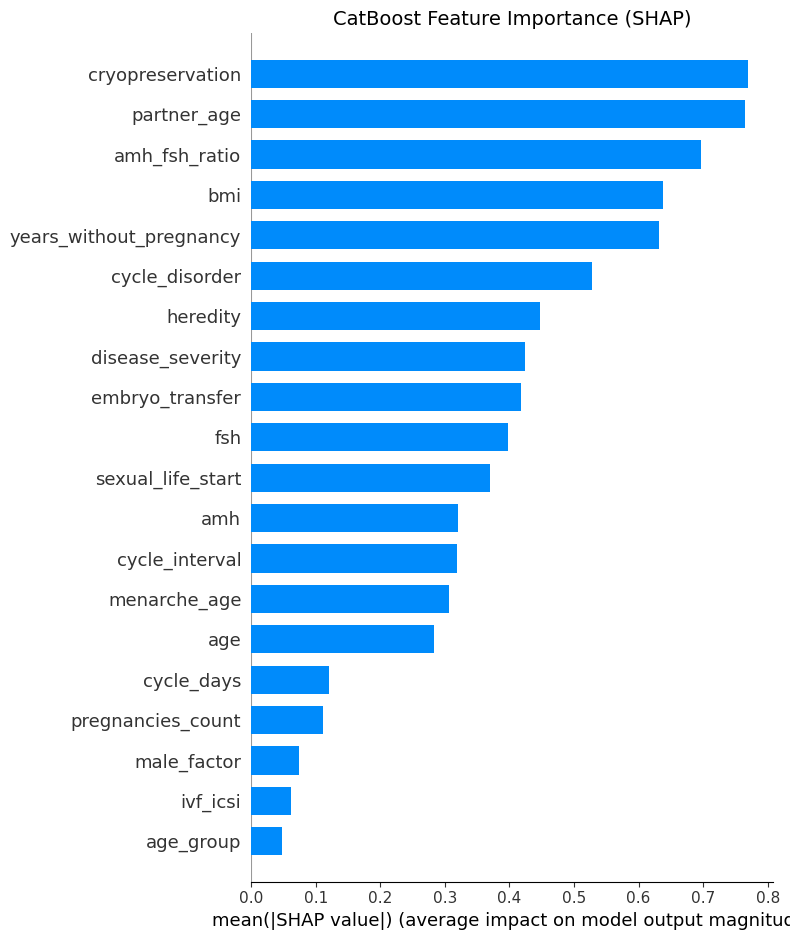

C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\1604962823.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_rg, show=False)


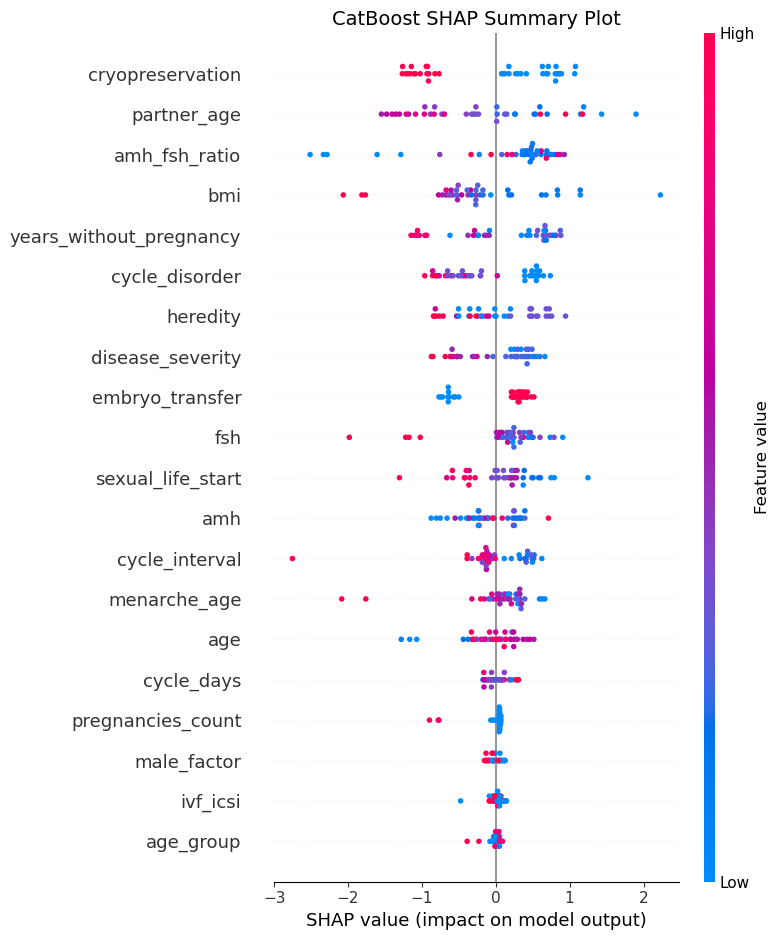

In [17]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(cat_model_final)

shap_values = explainer.shap_values(X_test_cat)

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_rg, plot_type="bar", show=False)
plt.title("CatBoost Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_catboost_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_rg, show=False)
plt.title("CatBoost SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.savefig("shap_catboost_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

### MLP

In [18]:
seed = 789

set_seed(seed)

final_mlp = train_mlp_final(
    X_train_val_p,
    pd.concat([y_train, y_val]),
    n_epochs=mlp_cv['cv_best_epoch']
)

best_thr = mlp_cv['cv_threshold']

final_mlp.eval()
with torch.no_grad():
    y_prob = torch.sigmoid(
        final_mlp(torch.tensor(X_test_p, dtype=torch.float32))
    ).numpy().flatten()

y_pred = (y_prob >= best_thr).astype(int)

Размер shap_values: (39, 30)
Размер of X_test_p: (39, 30)


C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\1174708241.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


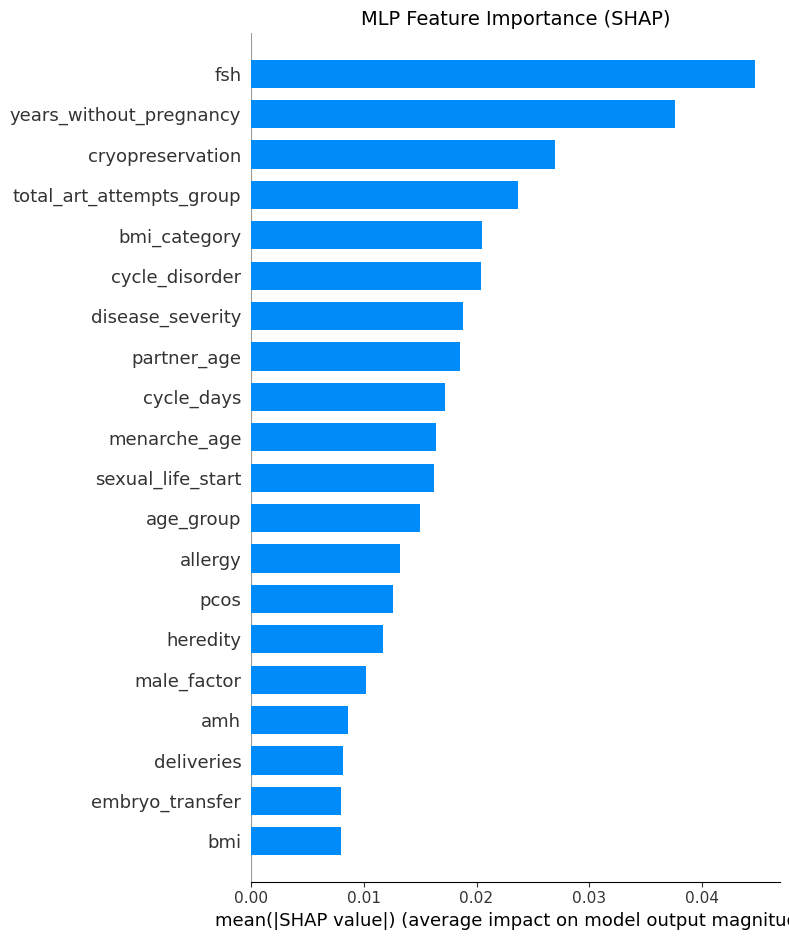

C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\1174708241.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


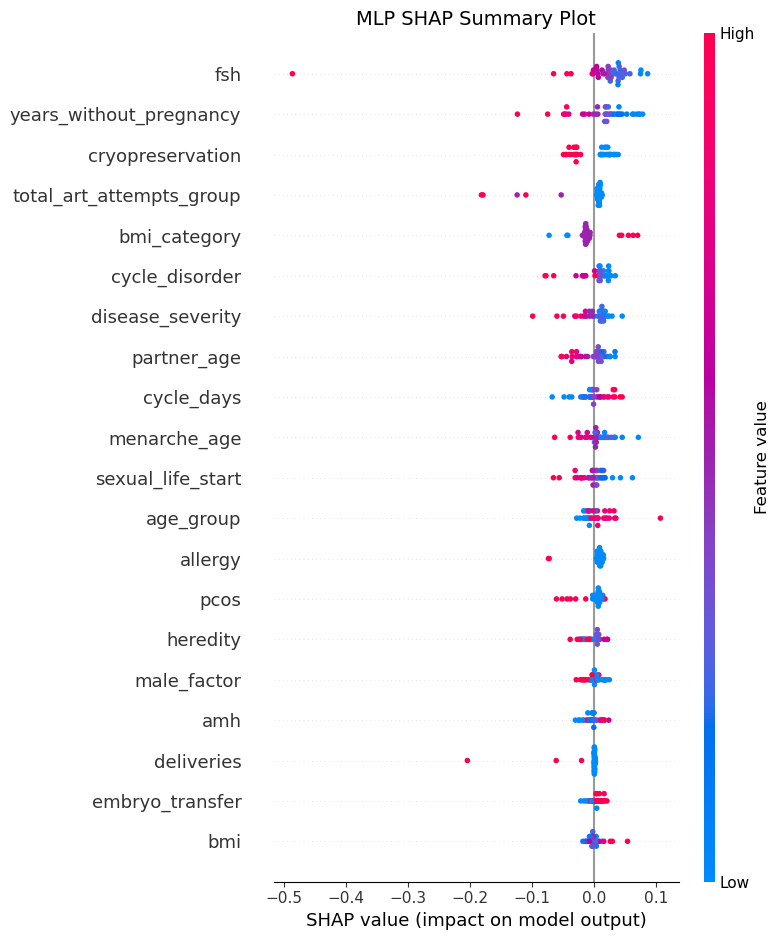

In [19]:
background = torch.tensor(X_train_val_p[:100], dtype=torch.float32)
test_tensor = torch.tensor(X_test_p, dtype=torch.float32)

explainer = shap.DeepExplainer(final_mlp, background)
shap_values = explainer.shap_values(test_tensor)

if isinstance(shap_values, list):
    shap_values = shap_values[0]                    
if len(shap_values.shape) == 3:
    shap_values = shap_values.squeeze(axis=-1)

print("Размер shap_values:", shap_values.shape)
print("Размер of X_test_p:", X_test_p.shape)

assert shap_values.shape[1] == X_test_p.shape[1], "Размеры не соответствуют!"

# Summary plot
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in feature_names]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    plot_type="bar", 
    show=False
)
plt.title("MLP Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_mlp_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    show=False
)
plt.title("MLP SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.savefig("shap_mlp_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

### Logistic Regression

Размер shap_values: (39, 30)
Размер X_test_p: (39, 30)


C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\3987586474.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_p, feature_names=clean_names,


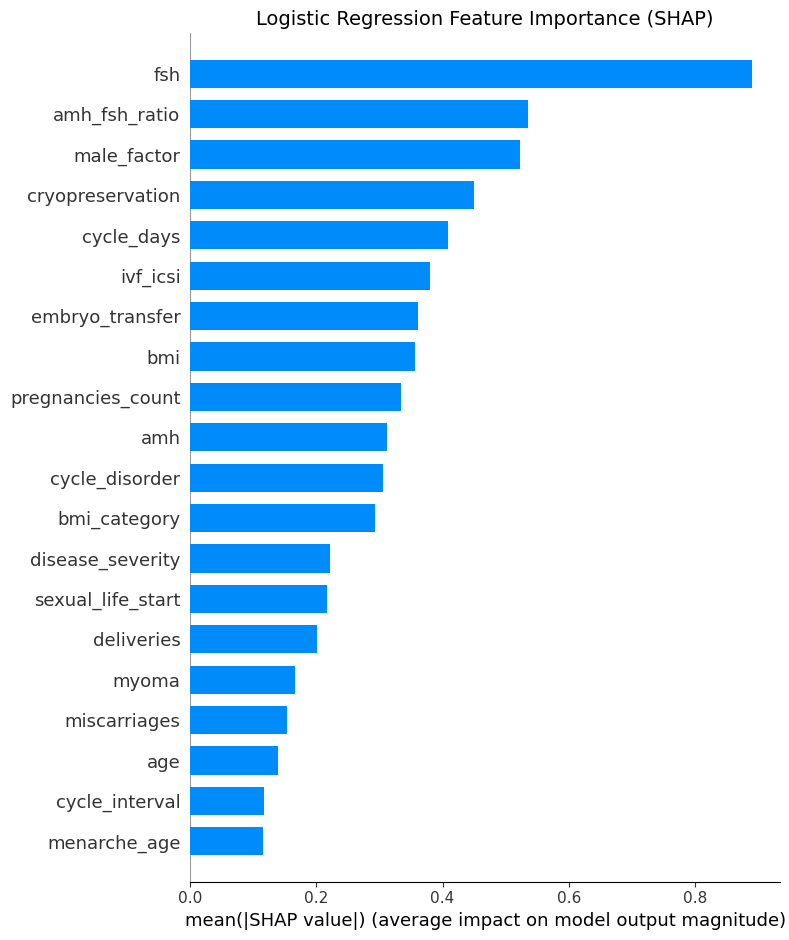

C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\3987586474.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_p, feature_names=clean_names, show=False)


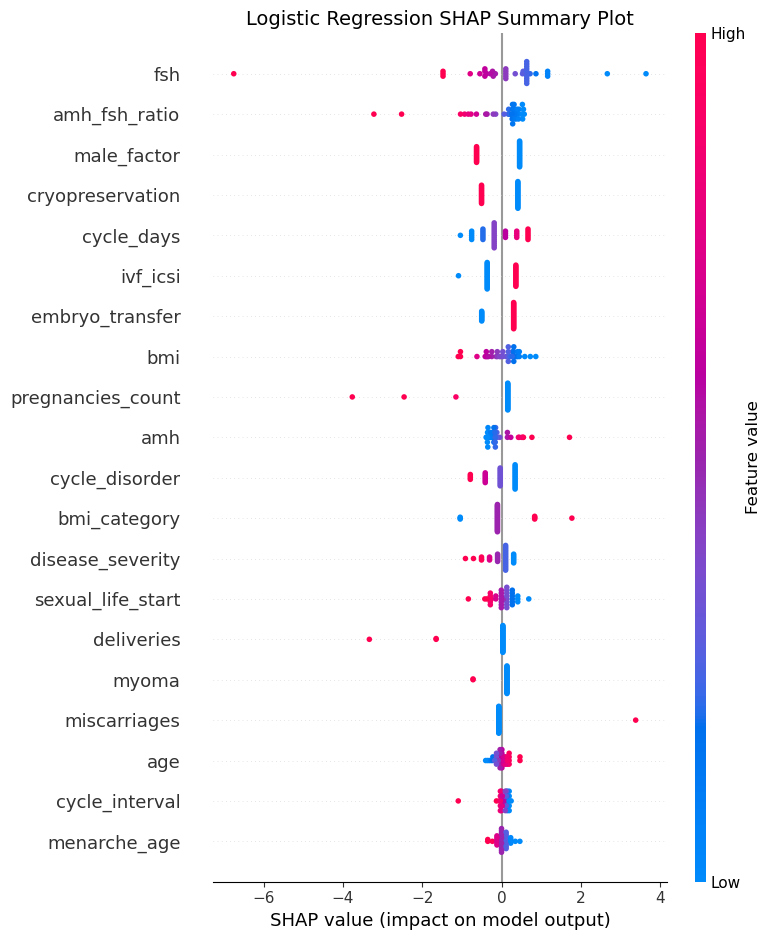

In [20]:
explainer = shap.LinearExplainer(logreg, X_train_val_p)
shap_values = explainer.shap_values(X_test_p)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("Размер shap_values:", shap_values.shape)
print("Размер X_test_p:", X_test_p.shape)

# Чистые имена признаков (убираем num__ и cat__)
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in feature_names]

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_p, feature_names=clean_names, 
                  plot_type="bar", show=False)
plt.title("Logistic Regression Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_lr_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_p, feature_names=clean_names, show=False)
plt.title("Logistic Regression SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.savefig("shap_lr_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


### Random Forest

Исходная форма: (39, 30)
После выбора класса 1: (39, 30)


C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\3407328422.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


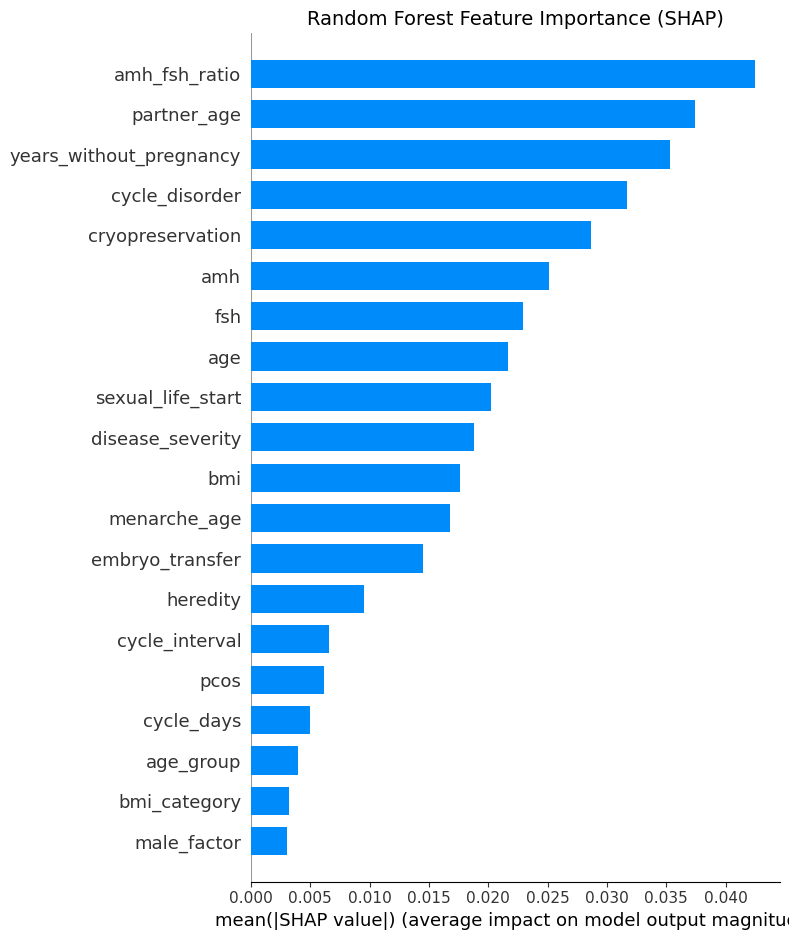

C:\Users\alisa\AppData\Local\Temp\ipykernel_11624\3407328422.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


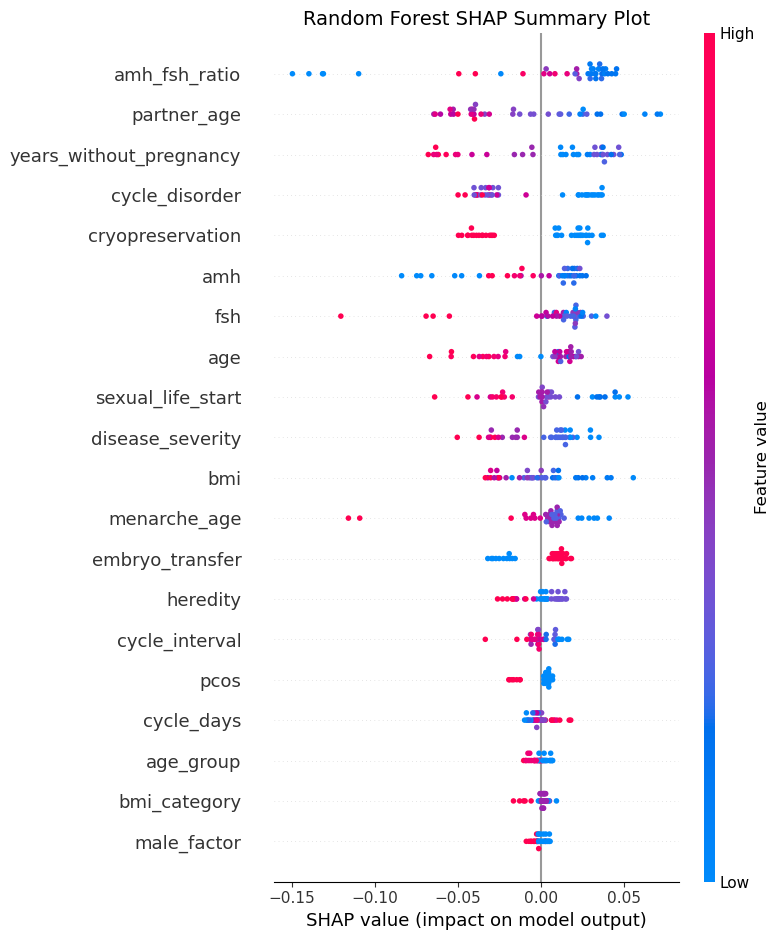

In [21]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_p)

if len(np.array(shap_values).shape) == 3:
    shap_values = np.array(shap_values)[:, :, 1]
elif isinstance(shap_values, list):
    shap_values = shap_values[1] 

print("Исходная форма:", shap_values.shape)

print("После выбора класса 1:", shap_values.shape)

# Чистые имена признаков
clean_names = [name.split('__')[-1] for name in preprocessor.get_feature_names_out()]

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    plot_type="bar",
    show=False,
    max_display=20         
)
plt.title("Random Forest Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_rf_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    show=False,
    max_display=20
)
plt.title("Random Forest SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.show()


# Confusion Matrix + клинических метрик

### Logistic Regression

LOGISTIC REGRESSION - Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 4 18]
 [ 4 13]]

Клинические метрики:
  TN                       : 4
  FP                       : 18
  FN                       : 4
  TP                       : 13
  Accuracy                 : 0.4359
  Sensitivity              : 0.7647
  Specificity              : 0.1818
  Precision                : 0.4194
  NPV                      : 0.5
  F1-score                 : 0.5417
  AUC-ROC                  : 0.5668


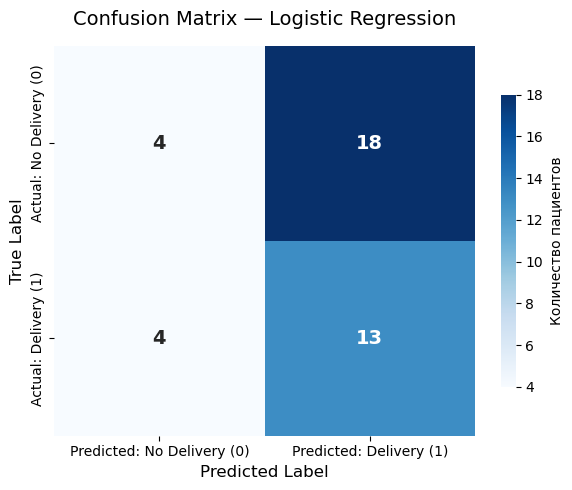

In [22]:
import seaborn as sns

y_prob_lr = logreg.predict_proba(X_test_p)[:, 1]
y_pred_lr = (y_prob_lr >= best_thr_lr).astype(int)

cm_lr, metrics_lr = calculate_clinical_metrics(
    y_true=y_test, 
    y_pred=y_pred_lr, 
    y_prob=y_prob_lr
)

print("=" * 60)
print("LOGISTIC REGRESSION - Confusion Matrix и клинические метрики")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm_lr)
print("\nКлинические метрики:")
for key, value in metrics_lr.items():
    print(f"  {key:25}: {value}")

# Визуализация

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                     
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — Logistic Regression", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_lr = pd.DataFrame([metrics_lr]).T
metrics_df_lr.columns = ['Logistic Regression']
metrics_df_lr.index.name = 'Metric'

### MLP

MLP (PyTorch) - Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 8 14]
 [ 3 14]]

Клинические метрики:
  TN                       : 8
  FP                       : 14
  FN                       : 3
  TP                       : 14
  Accuracy                 : 0.5641
  Sensitivity              : 0.8235
  Specificity              : 0.3636
  Precision                : 0.5
  NPV                      : 0.7273
  F1-score                 : 0.6222
  AUC-ROC                  : 0.7112


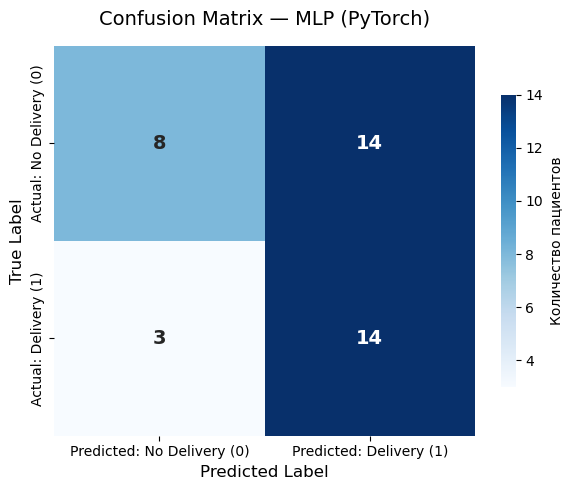

In [23]:
# Переводим в тензор
X_test_tensor = torch.tensor(X_test_p, dtype=torch.float32)

cm_mlp, metrics_mlp = calculate_clinical_metrics(
    y_true=y_test, 
    y_pred=y_pred, 
    y_prob=y_prob
)

print("=" * 60)
print("MLP (PyTorch) - Confusion Matrix и клинические метрики")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm_mlp)
print("\nКлинические метрики:")
for key, value in metrics_mlp.items():
    print(f"  {key:25}: {value}")

# Визуализация

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mlp, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                    
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — MLP (PyTorch)", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_mlp = pd.DataFrame([metrics_mlp]).T
metrics_df_mlp.columns = ['MLP']
metrics_df_mlp.index.name = 'Metric'

### Random Forest

RANDOM FOREST - Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 3 19]
 [ 1 16]]

Клинические метрики:
  TN                       : 3
  FP                       : 19
  FN                       : 1
  TP                       : 16
  Accuracy                 : 0.4872
  Sensitivity              : 0.9412
  Specificity              : 0.1364
  Precision                : 0.4571
  NPV                      : 0.75
  F1-score                 : 0.6154
  AUC-ROC                  : 0.6551


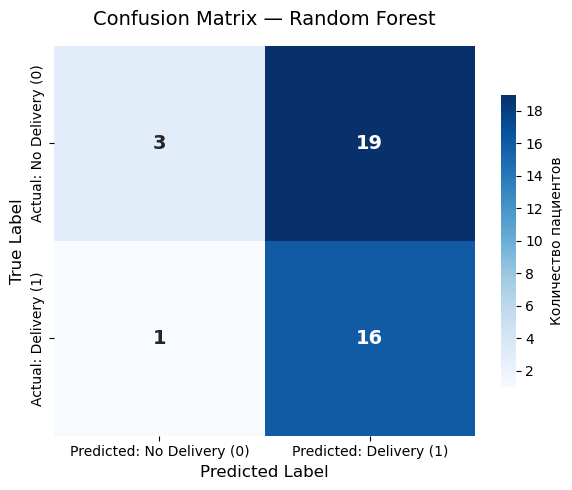

In [24]:
y_prob_rf = rf.predict_proba(X_test_p)[:, 1]
y_pred_rf = (y_prob_rf >= best_thr_rf).astype(int)

cm_rf, metrics_rf = calculate_clinical_metrics(
    y_true=y_test, 
    y_pred=y_pred_rf, 
    y_prob=y_prob_rf
)

print("=" * 60)
print("RANDOM FOREST - Confusion Matrix и клинические метрики")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm_rf)
print("\nКлинические метрики:")
for key, value in metrics_rf.items():
    print(f"  {key:25}: {value}")

# Визуализация Confusion Matrix

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                    
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — Random Forest", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_rf = pd.DataFrame([metrics_rf]).T
metrics_df_rf.columns = ['Random Forest']
metrics_df_rf.index.name = 'Metric'

### CatBoost

CATBOOST - Confusion Matrix и клинические метрики

Confusion Matrix:
[[16  6]
 [ 7 10]]

Клинические метрики:
  TN                       : 16
  FP                       : 6
  FN                       : 7
  TP                       : 10
  Accuracy                 : 0.6667
  Sensitivity              : 0.5882
  Specificity              : 0.7273
  Precision                : 0.625
  NPV                      : 0.6957
  F1-score                 : 0.6061
  AUC-ROC                  : 0.7059


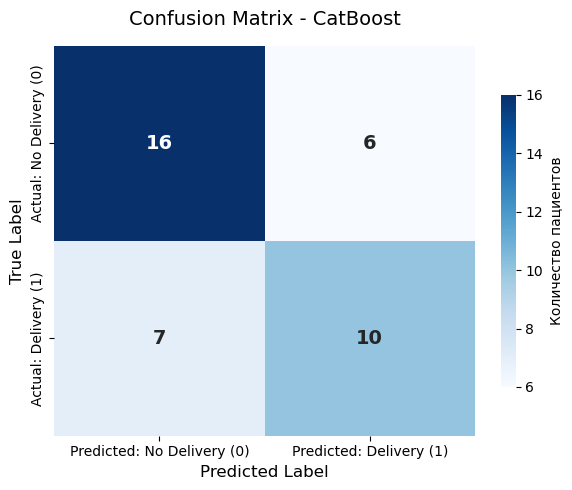

In [25]:
cm_cat, metrics_cat = calculate_clinical_metrics(y_test, test_pred_cat, test_prob_cat)

print("=" * 70)
print("CATBOOST - Confusion Matrix и клинические метрики")
print("=" * 70)
print("\nConfusion Matrix:")
print(cm_cat)
print("\nКлинические метрики:")
for key, value in metrics_cat.items():
    print(f"  {key:25}: {value}")

# Визуализация Confusion Matrix

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cat, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                    
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix - CatBoost", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_catboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_cat = pd.DataFrame([metrics_cat]).T
metrics_df_cat.columns = ['CatBoost']
metrics_df_cat.index.name = 'Metric'

# ROC curves

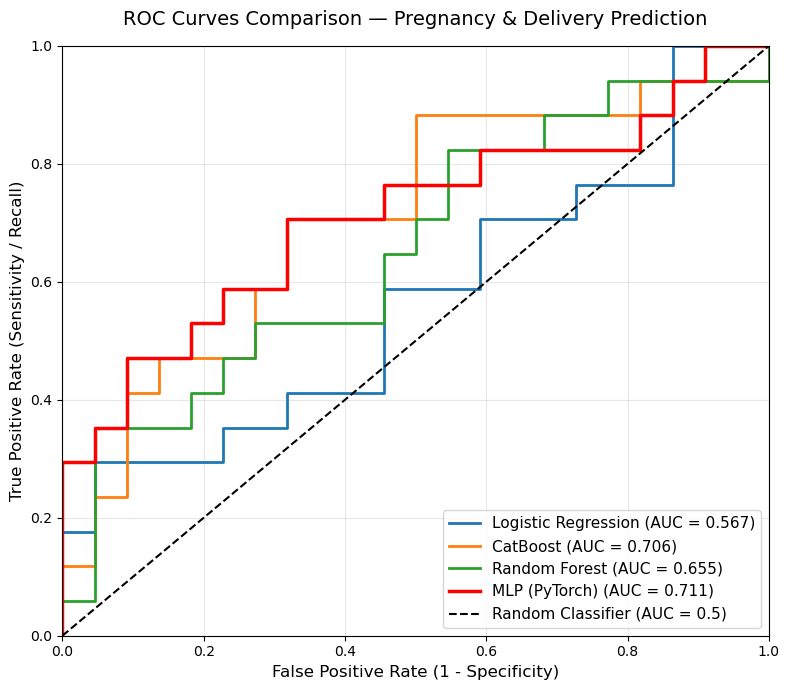


AUC-ROC на тестовом множестве:
  Logistic Regression : 0.5668
  CatBoost            : 0.7059
  Random Forest       : 0.6551
  MLP (PyTorch)       : 0.7112


In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Считаем ROC-кривые и AUC

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_cat, tpr_cat, _ = roc_curve(y_test, test_prob_cat)
auc_cat = roc_auc_score(y_test, test_prob_cat)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob)
auc_mlp = roc_auc_score(y_test, y_prob)

# График

plt.figure(figsize=(8, 7))

plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.3f})', linewidth=2)
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (PyTorch) (AUC = {auc_mlp:.3f})', linewidth=2.5, color='red')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1.5)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curves Comparison — Pregnancy & Delivery Prediction', fontsize=14, pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nAUC-ROC на тестовом множестве:")
print(f"  Logistic Regression : {auc_lr:.4f}")
print(f"  CatBoost            : {auc_cat:.4f}")
print(f"  Random Forest       : {auc_rf:.4f}")
print(f"  MLP (PyTorch)       : {auc_mlp:.4f}")